# Agent-Based Model of Household Water Conservation Interventions

## 1. Setup

In [35]:
# All imports used in this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import contextlib
from scipy.stats import shapiro, linregress
from statsmodels.stats.multitest import multipletests
import calendar
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.patheffects as pe
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

In [36]:
# Seed makes random sampling reproducible across runs
Seed = 67
RandomGenerator = np.random.default_rng(Seed)

# Load survey data (DatasetExperiment.csv must be in the same folder)
PathToData = "DatasetExperiment.csv"
Data = pd.read_csv(PathToData)
Data.columns = Data.columns.astype(str).str.strip()

# 500 synthetic agents, each sampled from one real survey respondent
NumberOfAgents = 500

# Simulation runs from April 2026 to December 2035 in weekly time steps
StartDateOfSimulation = pd.Timestamp("2026-04-01")
EndDateOfSimulation = pd.Timestamp("2035-12-31")
NumberOfWeeks = int((EndDateOfSimulation - StartDateOfSimulation).days // 7)

# First intervention opportunity is in January 2027
FirstDateOfIntervention = pd.Timestamp("2027-01-01")

# Participation rates from Fowlie et al. (2021):
# 0.20 (opt-in), 0.95 (opt-out)
MonthlyOptIn = 0.20
YearlyOptOutApril = 0.95

DaysPerWeek = 7

# Water target: 100 L/person/day × 7 days = 700 L/week (Algemene Rekenkamer, 2025)
WaterTargetDailyPerPerson = 100
WaterTarget = WaterTargetDailyPerPerson * DaysPerWeek


def GetWeekDate(Week):
    """Convert a week index to a calendar date."""
    return StartDateOfSimulation + pd.Timedelta(weeks=int(Week))


# Spring window weights: normalised counts of Dutch tax returns filed per week
# (Belastingdienst, 2025). Weeks are 7-day blocks from 1 March; week 9 is 5 days.
_AangifteRawCounts  = [2301172, 1546377, 1142449, 113764, 1036139, 633930, 741031, 850600, 1232882]
_AangifteTotalCount = sum(_AangifteRawCounts)
AangifteWeekWeights = [c / _AangifteTotalCount for c in _AangifteRawCounts]


def _AangifteWeekIndex(Date):
    """
    Return the filing week number (1–9) for dates in the spring window
    (1 March – 30 April).
    """
    if Date.month == 3:
        DayOfPeriod = Date.day - 1
    elif Date.month == 4:
        DayOfPeriod = Date.day - 1 + 31
    else:
        return None
    WeekIndex = DayOfPeriod // 7
    if WeekIndex > 8:
        return None
    return WeekIndex + 1


def InterventionProbabilityForWeek(Week):
    """
    Return the probability that an agent receives the intervention this week
    """
    CurrentDate = GetWeekDate(Week)

    if CurrentDate < FirstDateOfIntervention:
        return 0.0

    AangifteWeekIdx = _AangifteWeekIndex(CurrentDate)
    if AangifteWeekIdx is not None:
        return YearlyOptOutApril * AangifteWeekWeights[AangifteWeekIdx - 1]


    _, DaysInMonth = calendar.monthrange(CurrentDate.year, CurrentDate.month)
    WeeksInMonth   = max(1, -(-DaysInMonth // 7))  
    return 1 - (1 - MonthlyOptIn) ** (1 / WeeksInMonth)


## 2. Clean and prepare the data

The model uses six behaviours from the survey: shower frequency, shower duration,
and washing-machine frequency (should decrease); and turning off water while
showering, eco wash mode, and toilet small-flush use (should increase).
I didn't use full washing machines as that already is connected to washing-machine frequency

In [37]:
# Behaviours where lower values mean less water use
MinimiseBehaviours = ["NumberOfShowers", "ShowerDuration", "NumberOfWashing"]
# Behaviours where higher values mean less water use
MaximiseBehaviours = ["Turnwateroff", "WashMode", "FlushButton"]
AllBehaviours = MinimiseBehaviours + MaximiseBehaviours

T1, T2, T3 = "1", "2", "3"

def ColumnName(TimePoint, Behaviour):
    """Survey column name, e.g. '2:ShowerDuration'."""
    return f"{TimePoint}:{Behaviour}"

# Columns needed from the survey
KColumns        = ["k_T1", "k_T2", "k_T3"]
BehaviourColumns = [ColumnName(tp, b) for tp in [T1, T2, T3] for b in AllBehaviours]

for col in KColumns + BehaviourColumns:
    Data[col] = pd.to_numeric(Data[col], errors="coerce")

# Keep only complete rows
Data = Data.dropna(subset=KColumns + BehaviourColumns).copy()
print(f"Rows retained: {len(Data)}")

# Check that raw k is not normally distributed (justifies log transform)
# also done in other notebook, this is just a double check. 

display(pd.DataFrame({
    "Variable": ["k_T1", "k_T3"],
    "Shapiro_p": [shapiro(Data["k_T1"].dropna()).pvalue, shapiro(Data["k_T3"].dropna()).pvalue],}))

# k is skewed, so ln(k) is used throughout (Guo et al., 2022)
Data["LnkT1"] = np.log(Data["k_T1"])
Data["LnkT3"] = np.log(Data["k_T3"])

# Build synthetic population from a of sample 500 agents from real respondents with replacement
SampledRows = RandomGenerator.choice(Data.index, size=NumberOfAgents, replace=True)
Agents = Data.loc[SampledRows].reset_index(drop=True)
Agents["AgentId"] = np.arange(NumberOfAgents)

Rows retained: 108


,Variable,Shapiro_p
0,k_T1,8.690749e-22
1,k_T3,6.883706e-21


## 3. Empirical effects from the survey

This section derives the three model inputs that come from the survey:
the information effect, the EFT residual effect, and the sensitivity parameter γ
linking changes in ln(k) to intention changes.

In [38]:
# Change in ln(k) between T1 and T3
Data["DeltaLnk"] = Data["LnkT3"] - Data["LnkT1"]

# Intention changes for each behaviour
for b in AllBehaviours:
    Data[f"DeltaEft_{b}"]  = Data[ColumnName(T3, b)] - Data[ColumnName(T1, b)]
    Data[f"DeltaInfo_{b}"] = Data[ColumnName(T2, b)] - Data[ColumnName(T1, b)]


def RegressionStats(Predictor, Outcome):
    """One-variable regression: returns R2 and p-value"""
    x, y = np.asarray(Predictor, float), np.asarray(Outcome, float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    if len(x) < 3 or np.isclose(np.var(x), 0) or np.isclose(np.var(y), 0):
        return 0.0, np.nan
    r = linregress(x, y)
    return r.rvalue ** 2, r.pvalue


# p = R2 for each behaviour. Holm correction for multiple comparisons
RegressionTable = pd.DataFrame([
    {
        "Behaviour": b,
        "p":       RegressionStats(Data["DeltaLnk"], Data[f"DeltaEft_{b}"])[0],
        "p_value": RegressionStats(Data["DeltaLnk"], Data[f"DeltaEft_{b}"])[1],
    }
    for b in AllBehaviours
])
RegressionTable["p_holm"]          = multipletests(RegressionTable["p_value"], alpha=0.05, method="holm")[1]
RegressionTable["Significant_holm"] = RegressionTable["p_holm"] < 0.05
display(RegressionTable)

# ln(k) after s EFT sessions based on saturating curve from Mellis et al., 2019
# maximum reduction in ln(k)
DeltaEFT  = 2.8

# saturation rate
LambdaEFT = 0.55


def LnkAfterSession(LnkStart, Session):
    """Eq. 1: ln(k)_{i,s} = ln(k)_{i,T1} − Δ_EFT(1 − e^{−λs})"""
    return LnkStart - DeltaEFT * (1 - np.exp(-LambdaEFT * Session))

# ln(k) reduction after exactly one session
CalibrationLnkReduction = DeltaEFT * (1 - np.exp(-LambdaEFT))
ObservedLnkReduction    = (Data["LnkT1"] - Data["LnkT3"]).mean()

Gamma = {}
ResidualEft = {}
MeanInfoEffect = {}

for b in AllBehaviours:
    p_val              = RegressionTable.loc[RegressionTable["Behaviour"] == b, "p"].iloc[0]
    IndividualEftChange = Data[f"DeltaEft_{b}"].astype(float)

    # γ_i = p · ΔI_i / [ln(k)_{T1} − ln(k)_{s=1}]
    Gamma[b]       = p_val * IndividualEftChange / CalibrationLnkReduction

    # portion of intention change not linked to ln(k)
    ResidualEft[b] = (1 - p_val) * IndividualEftChange

    # Information effect
    MeanInfoEffect[b] = Data[f"DeltaInfo_{b}"].astype(float)

# Map per-respondent values onto agents via the same SampledRows used in Section 2
Gamma = {b: Gamma[b].loc[SampledRows].to_numpy(float) for b in AllBehaviours}
ResidualEft = {b: ResidualEft[b].loc[SampledRows].to_numpy(float) for b in AllBehaviours}
MeanInfoEffect = {b: MeanInfoEffect[b].loc[SampledRows].to_numpy(float) for b in AllBehaviours}

GammaTable = pd.DataFrame({
    "Behaviour": AllBehaviours,
    "Gamma (mean)": [Gamma[b].mean() for b in AllBehaviours],
    "Gamma (sd)": [Gamma[b].std() for b in AllBehaviours],
    "Info effect (mean)": [MeanInfoEffect[b].mean() for b in AllBehaviours],
    "Info effect (sd)": [MeanInfoEffect[b].std()  for b in AllBehaviours],
    "Observed ln(k) reduction T1–T3": ObservedLnkReduction,
    "Calibration ln(k) reduction s=1": CalibrationLnkReduction,}) 

print(GammaTable)

,Behaviour,p,p_value,p_holm,Significant_holm
0,NumberOfShowers,0.032007,0.063945,0.172951,False
1,ShowerDuration,0.099113,0.000905,0.004526,True
2,NumberOfWashing,0.003492,0.543524,0.543524,False
3,Turnwateroff,0.033581,0.057650,0.172951,False
4,WashMode,0.066184,0.007192,0.028767,True
5,FlushButton,0.176234,0.000006,0.000037,True


         Behaviour  Gamma (mean)  Gamma (sd)  Info effect (mean)  \
0  NumberOfShowers     -0.011889    0.041319              -0.220   
1   ShowerDuration     -0.209516    0.278391              -1.222   
2  NumberOfWashing     -0.000955    0.002758              -0.186   
3     Turnwateroff      0.030504    0.036594               0.542   
4         WashMode      0.037882    0.060958               0.388   
5      FlushButton      0.087779    0.163649               0.228   

   Info effect (sd)  Observed ln(k) reduction T1–T3  \
0          0.745386                       -0.042665   
1          2.086316                       -0.042665   
2          0.914004                       -0.042665   
3          0.969658                       -0.042665   
4          0.813299                       -0.042665   
5          0.753668                       -0.042665   

   Calibration ln(k) reduction s=1  
0                         1.184541  
1                         1.184541  
2                         

## 4. Intention updates and decay

Each behaviour has a target (formula sheet Table L2). Intervention effects are
scaled by the remaining distance to that target so agents cannot overshoot it.
After each session, intention decays back toward baseline following an exponential
decay equation (Duan et al., 2025). The decay constant τ grows with the number
of completed sessions because repetition reduces forgetting
(MacLeod et al., 2018; Rahman et al., 2021; Wang & Yang, 2024).


In [39]:
# Target values from formula sheet
BehaviourTargets = {
# showers/week
"NumberOfShowers": 2.0, 
 # minutes
"ShowerDuration":  5.0,  
# cycles/week
"NumberOfWashing": 1.0, 
# 1–5 Likert
"Turnwateroff":    5.0,  
# 1–5 Likert
"WashMode":        5.0,
# 1–5 Likert
"FlushButton":     5.0,
}
def PersonalTarget(Behaviour, BaselineValues):
    """
    Agents already at or past the target keep their baseline value so the intervention
    does not push them in the wrong direction.
    """
    BaselineValues = np.asarray(BaselineValues, float)
    Target = BehaviourTargets[Behaviour]
    if Behaviour in MinimiseBehaviours:
        return np.where(BaselineValues <= Target, BaselineValues, Target)
    return np.where(BaselineValues >= Target, BaselineValues, Target)


def ScaledResidual(Behaviour, CurrentValues, BaselineValues, RawEffect):
    """
    Scale the intervention effect by the fraction of the distance to the target still remaining.
    Returns zero when the agent has already reached the target.
    """
    CurrentValues = np.asarray(CurrentValues,  float)
    BaselineValues = np.asarray(BaselineValues, float)
    TargetValues = PersonalTarget(Behaviour, BaselineValues)
    InitialGap = TargetValues - BaselineValues
    Scale = np.zeros_like(CurrentValues, float)
    Valid  = np.abs(InitialGap) > 1e-12
    Scale[Valid] = (TargetValues[Valid] - CurrentValues[Valid]) / InitialGap[Valid]
    Scale = np.clip(Scale, 0, 1)
    return RawEffect * Scale

def ClipIntentions(Intentions):
    """Keep intention values inside plausible survey ranges."""
    Clipped = Intentions.copy()
    for b in MinimiseBehaviours:
        Clipped[b] = np.maximum(0, np.asarray(Clipped[b], float))
    for b in MaximiseBehaviours:
        Clipped[b] = np.clip(np.asarray(Clipped[b], float), 1, 5)
    return Clipped

def ApplyEft(Intentions, BaselineIntentions, LnkStart, SessionCount):
    """
    EFT intention update
    """
    NewIntentions = Intentions.copy()
    PreviousLnk = LnkAfterSession(LnkStart, SessionCount - 1)
    CurrentLnk = LnkAfterSession(LnkStart, SessionCount)
    LnkDrop = PreviousLnk - CurrentLnk

    for b in AllBehaviours:
        ResidualChange = ScaledResidual(b, NewIntentions[b], BaselineIntentions[b], ResidualEft[b])
        NewIntentions[b] = NewIntentions[b] + ResidualChange + Gamma[b] * LnkDrop
    
    return ClipIntentions(NewIntentions)

def ApplyInfo(Intentions, BaselineIntentions):
    """
    information intention update
    Same structure as EFT but without a ln(k) term, because information
    does not reduce delay discounting (Rung & Madden, 2018).
    """
    NewIntentions = Intentions.copy()
    for b in AllBehaviours:
        InfoChange = ScaledResidual(b, NewIntentions[b], BaselineIntentions[b], MeanInfoEffect[b])
        NewIntentions[b] = NewIntentions[b] + InfoChange
    return ClipIntentions(NewIntentions)

# Decay parameters (formula sheet, decay section):
# EFT: τ_0 = 25 days (Duan et al., 2025 average doubled for EFT memory encoding;
#  Schacter, 2012), τ_max = 180 days, μ = 0.4
# Information: τ_0 = 13 days (Duan et al., 2025), τ_max = 30 days, μ = 0.4
Tau0Eft = 25;  TauMaxEft  = 180;  MuEft  = 0.4
Tau0Info = 13;  TauMaxInfo = 30;   MuInfo = 0.4

def TauEft(SessionCount):
    return TauMaxEft - (TauMaxEft - Tau0Eft) * np.exp(-MuEft * SessionCount)

def TauInfo(SessionCount):
    return TauMaxInfo - (TauMaxInfo - Tau0Info) * np.exp(-MuInfo * SessionCount)

def Decay(Intentions, BaselineIntentions, Tau):
    """
    Applied once per week
    """
    Decayed = Intentions.copy()
    RemainingFraction = np.exp(-DaysPerWeek / Tau)
    for b in AllBehaviours:
        Base = np.asarray(BaselineIntentions[b], float)
        Current = np.asarray(Intentions[b], float)
        Decayed[b] = Base + (Current - Base) * RemainingFraction
    return ClipIntentions(Decayed)


## 5. Weekly water use

Intentions are translated into weekly household water use following the
formula sheet (Eqs. 32–36). The three categories are showering, washing-machine
use, and toilet flushing. Sources: Milieu Centraal (2023), CBS (2021, 2022),
Vitens (2024, 2026), López Zavala et al. (2016), Rosa & Ghisi (2021).

The intention–behaviour gap (α_IB = 0.50) is applied after computing
intended water use, so only half of any intention change becomes actual
behaviour change (Sheeran & Gollwitzer, 2015).


In [40]:
# Fixed water-use parameters from the formula sheet
StandardShowerFlow = 7.3    # L/min (standard showerhead)
SavingShowerFlow = 4.0    # L/min (water-saving showerhead)
RainShowerFlow = 10.22  # L/min (rain shower)
WaterOffDuration = 6.0    # minutes saved per shower by turning off water (Vitens, 2026)
WashingMachineLitres = 49.0  # L/cycle (CBS, 2021)
EcoModeSaving = 0.40  # fraction saved in eco mode (Vitens, 2024)
WeeklyToiletFlushes = 41.3   # flushes per week (CBS, 2022; Burgio et al., 1991)
FullFlushLitres = 6.7    # L/flush
SmallFlushLitres = 3.7    # L/flush
GreywaterCorrection = 0.59   # factor when greywater/rainwater is used (López Zavala et al., 2016; Rosa & Ghisi, 2021)

def FlowRate(ShowerheadText):
    """Select showerhead flow rate from survey answer."""
    t = str(ShowerheadText).lower()
    if "saving" in t or "water-saving" in t:
        return SavingShowerFlow
    if "rain" in t:
        return RainShowerFlow
    return StandardShowerFlow

def YesBinary(Value):
    """Convert yes/no to 1/0."""
    return 1.0 if str(Value).strip().lower() in ["yes", "ja", "true", "1"] else 0.0


def LikertProbability(Value):
    """Map a 1–5 Likert scale to [0, 1]."""
    return np.clip((np.asarray(Value, float) - 1) / 4, 0, 1)

Agents["FlowRate"] = Agents["Showerhead"].apply(FlowRate)
Agents["GreywaterBinary"] = Agents["Greywater"].apply(YesBinary)

def WeeklyWater(Intentions):
    """
    Total weekly household water use from showering, washing-machine use, and toilet flushing.
    """
    N_shower = np.maximum(0, np.asarray(Intentions["NumberOfShowers"], float))
    D_shower = np.maximum(0, np.asarray(Intentions["ShowerDuration"],  float))
    T_off = LikertProbability(np.asarray(Intentions["Turnwateroff"],  float))
    F = Agents["FlowRate"].to_numpy(float)

    # The shower water use, minimum 1 L to avoid negative values
    ShowerWater = np.maximum(1, N_shower * D_shower * F - T_off * WaterOffDuration * F)

    # Washing-machine water use
    N_wash = np.maximum(0, np.asarray(Intentions["NumberOfWashing"], float))
    EcoUse = LikertProbability(np.asarray(Intentions["WashMode"], float))
    WashWater = N_wash * WashingMachineLitres * (1 - EcoModeSaving * EcoUse)

    # Toilet water use
    SmallFlush = LikertProbability(np.asarray(Intentions["FlushButton"], float))
    GreyFactor = np.where(Agents["GreywaterBinary"].to_numpy(float) == 1, GreywaterCorrection, 1.0)
    ToiletWater = WeeklyToiletFlushes * (SmallFlush * SmallFlushLitres + (1 - SmallFlush) * FullFlushLitres) * GreyFactor

    return ShowerWater + WashWater + ToiletWater

# Intention–behaviour gap 0.50 (Sheeran & Gollwitzer, 2015)
AlphaIB = 0.50

def IntentionBehaviourGap(WeeklyWaterFromIntentions, BaselineWater):
    """
    Only the intervention-induced change is scaled, baseline water use is unchanged.
    """
    return BaselineWater + AlphaIB * (WeeklyWaterFromIntentions - BaselineWater)

BaselineIntentions = pd.DataFrame({b: Agents[ColumnName(T1, b)].to_numpy(float) for b in AllBehaviours})
BaselineWater = WeeklyWater(BaselineIntentions)

print(f"Mean baseline weekly water use: {BaselineWater.mean():.1f} liters a week")
print(f"Mean baseline daily water use: {BaselineWater.mean() / 7:.1f} liters a day")
print(f"Weekly target: {WaterTarget:.0f} liters a week")


Mean baseline weekly water use: 797.9 liters a week
Mean baseline daily water use: 114.0 liters a day
Weekly target: 700 liters a week


## 6. Social comparison

Agents who adopt the smart-meter app (p_adopt = 0.78; Koop et al., 2021)
receive weekly social-comparison feedback. The norm is the median water use
among app adopters. The social adjustment rate φ is calibrated from field
experiments (Ferraro & Price, 2013; Brent et al., 2015;  = 0.049 over 4 weeks).
Agent responsiveness is heterogeneous: 56.1% of treated agents are
non-responders (r = 0; Otaki et al., 2024); the rest draw from a
truncated-normal distribution scaled so that E[r] ≈ 1 across all adopters.
The boomerang effect (p) controls whether below-norm agents drift upward.
p = 1 allows it; p = 0 (injunctive scenario) suppresses it.


In [41]:
# weekly social adjustment rate calibrated from 0.049 over 4 weeks
DeltaSocial = 0.049
SocialCalibrationWeeks = 4
Phi = 1 - (1 - DeltaSocial) ** (1 / SocialCalibrationWeeks) # = 0.0123...

# App adoption p_adopt = 0.78 (Koop et al., 2021)
PAdopt = 0.78
AdoptionGenerator = np.random.default_rng(Seed + 1)
AppAdopter = AdoptionGenerator.random(NumberOfAgents) < PAdopt

# Non-responder share = p_0 = 0.561 (Otaki et al., 2024)
NonResponderShare = 0.561
MeanResponder = 1 / (1 - NonResponderShare)
SdResponder  = 0.5

def DrawTruncatedNormal(Mean, Sd, Lower, Upper, Size, Generator):
    """Sample from a lower-truncated normal without scipy, using rejection sampling."""
    Values = np.empty(Size, float)
    Filled = 0
    while Filled < Size:
        Draw = Generator.normal(Mean, Sd, size=max(1000, 2 * (Size - Filled)))
        Draw = Draw[(Draw >= Lower) & (Draw <= Upper)]
        n    = min(Size - Filled, Draw.size)
        if n > 0:
            Values[Filled:Filled + n] = Draw[:n]
            Filled += n
    return Values

# Draw individual responsiveness multipliers r
ResponderGenerator = np.random.default_rng(Seed + 2)
NonResponderGenerator = np.random.default_rng(Seed + 3)
ResponderValues = DrawTruncatedNormal(MeanResponder, SdResponder, 0.0, np.inf, NumberOfAgents, ResponderGenerator)
IsNonResponder = NonResponderGenerator.random(NumberOfAgents) < NonResponderShare
Responsiveness = np.where(IsNonResponder, 0.0, ResponderValues)

# Agent-specific weekly adjustment rate
AgentPhi = np.where(AppAdopter, Responsiveness * Phi, 0.0)

RhoBoomerang  = 1 # upward adjustment allowed (boomerang scenario)
RhoInjunctive = 0 # upward adjustment suppressed (injunctive scenario)

def SocialComparison(WaterUse, PhiValues, Rho=RhoBoomerang, Adopters=None):
    """
    Social comparison update (formula sheet):
    Norm is the median water use among app adopters.
    Non-adopters are not updated.
    """
    WaterUse  = np.asarray(WaterUse, float)
    PhiValues = np.asarray(PhiValues, float)
    Adopters  = (PhiValues > 0) if Adopters is None else np.asarray(Adopters, bool)
    NewWater  = WaterUse.copy()

    if not Adopters.any():
        return NewWater

    Norm = np.median(WaterUse[Adopters])
    Difference = WaterUse - Norm
    Adjustment = np.where(Difference > 0,  PhiValues * Difference, np.where(Difference < 0, Rho * PhiValues * Difference, 0.0),)
    NewWater[Adopters] = WaterUse[Adopters] - Adjustment[Adopters]
    return np.maximum(0, NewWater)

## 7. Run the ABM

Three conditions are simulated: baseline (no intervention), information, and EFT.
Each week the model:
1. Draws whether each agent receives the intervention this week.
2. Updates intentions
3. Translates intentions to weekly water use
4. Applies social-comparison feedback for app adopters.
5. Decays intentions back toward baseline

noise is added only to the observed output to simulate realistic household-level week-to-week variation.


In [42]:
 # Weekly household noise standard deviation
SigmaNoise = 8.0

# Autocorrelation for noise
PhiAr      = 0.50 

def RunModel(Condition, KeepAgents=False, PhiValues=AgentPhi,
             AdoptersMask=AppAdopter, RhoValue=RhoBoomerang):
    """
    Run the ABM for one condition and one social-feedback configuration.
    Returns a weekly summary DataFrame (and optionally an agent-level DataFrame).
    """
    Intentions     = {b: BaselineIntentions[b].to_numpy(float).copy() for b in AllBehaviours}
    EftSessionCount  = np.zeros(NumberOfAgents, int)
    InfoSessionCount = np.zeros(NumberOfAgents, int)

    WeeklyRecords = []
    AgentRecords  = []

    SocialWaterState     = None
    PreviousActualWater  = None

    SeedOffset           = {"baseline": 101, "information": 202, "eft": 303}.get(Condition, 999)
    InterventionGenerator = np.random.default_rng(Seed + 50_000 + SeedOffset)
    NoiseGenerator        = np.random.default_rng(Seed + SeedOffset)

    NoiseState       = np.zeros(NumberOfAgents)
    NoiseInnovationSd = SigmaNoise * np.sqrt(1 - PhiAr ** 2)

    for Week in range(NumberOfWeeks + 1):
        WeekDate              = GetWeekDate(Week)
        InterventionProbability = InterventionProbabilityForWeek(Week)
        IntervenedThisWeek    = np.zeros(NumberOfAgents, bool)

        # intervention
        if InterventionProbability > 0 and Condition in ["information", "eft"]:
            IntervenedThisWeek = InterventionGenerator.random(NumberOfAgents) < InterventionProbability

            if Condition == "information":
                InfoSessionCount[IntervenedThisWeek] += 1
                UpdatedIntentions = ApplyInfo(Intentions, BaselineIntentions)
            else:
                EftSessionCount[IntervenedThisWeek] += 1
                UpdatedIntentions = ApplyEft(
                    Intentions, BaselineIntentions,
                    LnkStart=Agents["LnkT1"].to_numpy(float),
                    SessionCount=np.maximum(EftSessionCount, 1),
                )

            for b in AllBehaviours:
                Intentions[b] = np.where(IntervenedThisWeek, UpdatedIntentions[b], Intentions[b])

        # Water use and intention–behaviour gap
        WeeklyWaterFromIntentions = WeeklyWater(Intentions)
        ActualWater = IntentionBehaviourGap(WeeklyWaterFromIntentions, BaselineWater)

        # Social comparison carries forward as a water-use state
        if Week == 0:
            SocialWaterState    = ActualWater.copy()
            PreviousActualWater = ActualWater.copy()
        else:
            IndividualChange = ActualWater - PreviousActualWater
            SocialWaterState = np.clip(SocialWaterState + IndividualChange, 0, None)
            PreviousActualWater = ActualWater.copy()

        SocialWater      = SocialComparison(SocialWaterState, PhiValues, Rho=RhoValue, Adopters=AdoptersMask)
        SocialWaterState = SocialWater.copy()

        # Noise added to observed output only
        NoiseState   = PhiAr * NoiseState + NoiseGenerator.normal(0, NoiseInnovationSd, size=NumberOfAgents)
        ObservedWater = np.clip(SocialWater + NoiseState, 0, None)

        WeeklyRecords.append({ "week": Week, "date": WeekDate, "condition": Condition,
            "mean_water": ObservedWater.mean(), "distance": ObservedWater.mean() - WaterTarget, "n_intervened": int(IntervenedThisWeek.sum()),
            "intervention_probability": float(InterventionProbability), "eft_session": int(EftSessionCount.max()), "info_session": int(InfoSessionCount.max()),
            "mean_noise": float(NoiseState.mean()), "sd_noise": float(NoiseState.std()),})

        if KeepAgents:
            for i, w in enumerate(ObservedWater):
                AgentRecords.append({
                    "week": Week, "date": WeekDate, "condition": Condition,
                    "agent_id": i, "water_use": w,"water_use_without_noise": float(SocialWater[i]),
                    "noise_i": float(NoiseState[i]), "intervened_this_week":   bool(IntervenedThisWeek[i]),
                    "has_app": bool(AdoptersMask[i]), "phi_agent": float(PhiValues[i]), })

        # Decay
        if Condition == "information":
            Intentions = Decay(Intentions, BaselineIntentions, TauInfo(InfoSessionCount))
        elif Condition == "eft":
            Intentions = Decay(Intentions, BaselineIntentions, TauEft(EftSessionCount))
        else:
            # Baseline
            Intentions = {b: BaselineIntentions[b].to_numpy(float).copy() for b in AllBehaviours}

    MeanResults = pd.DataFrame(WeeklyRecords)
    if KeepAgents:
        return MeanResults, pd.DataFrame(AgentRecords)
    return MeanResults


# Three social-feedback scenarios
SocialScenarios = {
    "No comparative feedback": {"phi": np.zeros(NumberOfAgents), "rho": RhoBoomerang, "adopters": np.zeros(NumberOfAgents, bool)},
  "Comparative feedback": {"phi": AgentPhi.copy(), "rho": RhoBoomerang, "adopters": AppAdopter.copy()},
    "Comparative feedback + injunctive": {"phi": AgentPhi.copy(), "rho": RhoInjunctive, "adopters": AppAdopter.copy()},}

ConditionOrder = ["baseline", "information", "eft"]
ScenarioOrder  = ["No comparative feedback", "Comparative feedback", "Comparative feedback + injunctive"]
ScenarioResults = {}
AgentFrames     = []


for ScenarioName in ScenarioOrder:
    Settings = SocialScenarios[ScenarioName]
    for Condition in ConditionOrder:
        MeanResults, AgentResults = RunModel(
            Condition, KeepAgents=True,
            PhiValues=Settings["phi"], AdoptersMask=Settings["adopters"], RhoValue=Settings["rho"],
        )
        MeanResults["scenario"] = ScenarioName
        AgentResults["scenario"] = ScenarioName
        AgentResults["rho"]     = Settings["rho"]
        ScenarioResults[(ScenarioName, Condition)] = MeanResults
        AgentFrames.append(AgentResults)
    print(f"  done!!: {ScenarioName}")

SocialAgentResults = pd.concat(AgentFrames, ignore_index=True)

  done!!: No comparative feedback
  done!!: Comparative feedback
  done!!: Comparative feedback + injunctive


## 8. Results plots

**Plot 1** shows 15 randomly sampled agents under EFT across the three
social-feedback scenarios, illustrating individual heterogeneity. The bold line
is the mean across all 500 agents. The dashed line marks the 700 L/week target.

**Plot 2** shows mean weekly water use for all conditions and scenarios.
Baseline = dotted, information = dashed, EFT = solid. Orange ticks mark the
annual spring intervention (opt-out, April) and purple ticks mark monthly
voluntary interventions (opt-in).

**Plot 3** shows how the final-year mean water use changes as the boomerang
parameter ρ varies from 0 (no upward adjustment) to 1 (full boomerang effect).


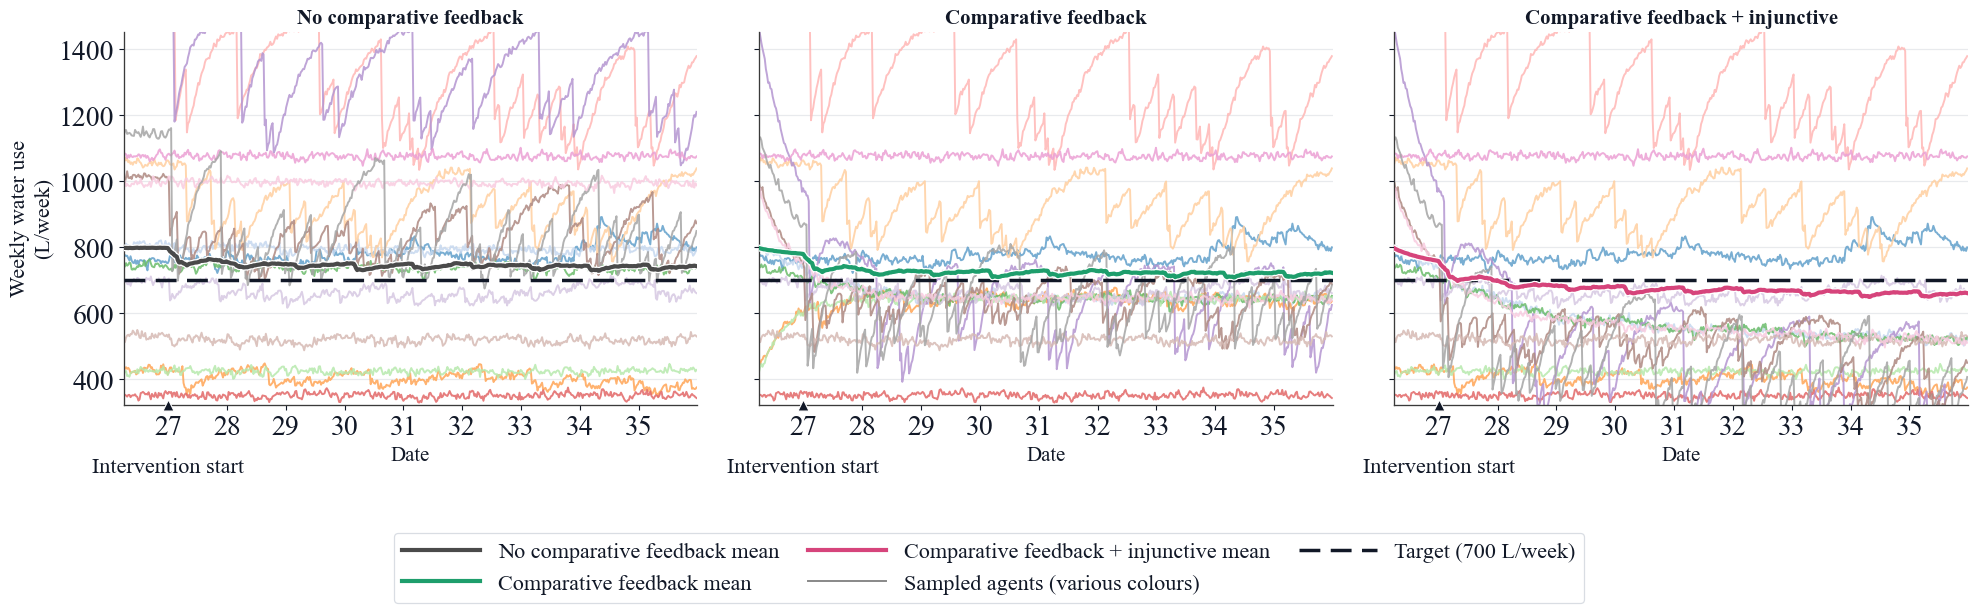

In [43]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",

    "xtick.labelsize": 20,
    "ytick.labelsize": 20,

    "axes.linewidth": 1.0,
    "axes.edgecolor": "#3A3A3A",
    "axes.labelcolor": "#111827",
    "xtick.color": "#111827",
    "ytick.color": "#111827",
    "text.color": "#111827",
    "savefig.dpi": 450,
})

MeanLineWidth        = 3.0
AgentLineWidth       = 1.4
AgentAlphaFaceted    = 0.85
GridColor            = "#E6E8EB"
TargetColor          = "#111827"
InterventionMarkerColor = "#111827"

ScenarioColors = {
    "No comparative feedback":           "#4A4A4A",
    "Comparative feedback":              "#1E9E6C",
    "Comparative feedback + injunctive": "#D6447B",
}

ConditionForPlot        = "eft"
NumberOfPlottedAgents   = 15
AgentColorMuteAmount    = 0.30
AgentSampleSeed         = 100
PlotFigureWidth, PlotFigureHeight = 20.0, 6.8

def mute_color(color, amount=0.30):
    rgb   = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return mcolors.to_hex((1 - amount) * rgb + amount * white)

def apply_thesis_style(ax):
    ax.set_facecolor("white")
    ax.grid(axis="y", color=GridColor, linewidth=0.9, alpha=0.9, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#3A3A3A")
    ax.spines["bottom"].set_color("#3A3A3A")
    ax.spines["left"].set_linewidth(0.95)
    ax.spines["bottom"].set_linewidth(0.95)

def format_year_axis(ax):
    # Toon alleen de laatste twee cijfers van het jaar: 2027 -> 27
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%y"))

def add_target_line(ax, label=True):
    ax.axhline(
        WaterTarget,
        color=TargetColor,
        linestyle=(0, (6, 3)),
        linewidth=2.5,
        label=f"Target ({WaterTarget:.0f} L/week)" if label else None,
        zorder=3,
    )

def add_intervention_marker(ax, show_label=False):
    # Aligned with FirstDateOfIntervention (cell 2): the model's first
    # actual intervention opportunity is January 2027, not July 2026.
    date_num = mdates.date2num(FirstDateOfIntervention)
    ax.scatter(
        [date_num],
        [0],
        transform=ax.get_xaxis_transform(),
        marker="^",
        s=64,
        color=InterventionMarkerColor,
        edgecolor="white",
        linewidth=0.8,
        clip_on=False,
        zorder=20,
    )
    if show_label:
        ax.annotate(
            "Intervention start",
            xy=(date_num, 0),
            xycoords=ax.get_xaxis_transform(),
            xytext=(0, -38),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=16,
            fontweight="normal",
            color=InterventionMarkerColor,
            annotation_clip=False,
            zorder=20,
        )

def save_figure(base_name):
    plt.savefig(f"{base_name}.pdf", bbox_inches="tight", facecolor="white")
    plt.savefig(f"{base_name}.png", dpi=450, bbox_inches="tight", facecolor="white")

# willekeurige subset van agenten
SampleAgentIds = (
    SocialAgentResults["agent_id"]
    .drop_duplicates()
    .sample(NumberOfPlottedAgents, random_state=AgentSampleSeed)
    .tolist()
)

# zachte kleuren voor agenten
AgentColorPalette = [
    mute_color(mcolors.to_hex(cm.tab20(i % 20)), amount=AgentColorMuteAmount)
    for i in range(NumberOfPlottedAgents)
]
AgentColorMap = dict(zip(SampleAgentIds, AgentColorPalette))

SubsetAll = SocialAgentResults[
    (SocialAgentResults["condition"] == ConditionForPlot)
    & (SocialAgentResults["agent_id"].isin(SampleAgentIds))
]

YMin = max(0, SubsetAll["water_use"].quantile(0.02) - 20)
YMax = SubsetAll["water_use"].quantile(0.98) + 20
YMin = min(YMin, WaterTarget - 40)
YMax = max(YMax, WaterTarget + 40)

fig, axes = plt.subplots(
    1,
    len(ScenarioOrder),
    figsize=(PlotFigureWidth, PlotFigureHeight),
    sharey=True,
    sharex=True,
)

for idx, scenario_name in enumerate(ScenarioOrder):
    ax = axes[idx]

    scenario_data = SocialAgentResults[
        (SocialAgentResults["scenario"] == scenario_name)
        & (SocialAgentResults["condition"] == ConditionForPlot)
    ]

    # individuele agentlijnen
    for agent_id in SampleAgentIds:
        agent_data = scenario_data[scenario_data["agent_id"] == agent_id]
        ax.plot(
            agent_data["date"],
            agent_data["water_use"],
            color=AgentColorMap[agent_id],
            alpha=AgentAlphaFaceted,
            linewidth=AgentLineWidth,
            zorder=2,
        )

    # gemiddelde lijn
    mean_line = (
        scenario_data.groupby("date")["water_use"]
        .mean()
        .reset_index()
    )
    ax.plot(
        mean_line["date"],
        mean_line["water_use"],
        color=ScenarioColors[scenario_name],
        linewidth=MeanLineWidth,
        zorder=5,
        path_effects=[
            pe.Stroke(linewidth=MeanLineWidth + 1.8, foreground="white"),
            pe.Normal(),
        ],
    )

    add_target_line(ax, label=(idx == 0))
    add_intervention_marker(ax, show_label=True)

    ax.set_xlim(StartDateOfSimulation, EndDateOfSimulation)
    ax.set_ylim(YMin, YMax)
    ax.margins(x=0.01)

    format_year_axis(ax)
    apply_thesis_style(ax)

    ax.set_title(scenario_name, fontsize=15, fontweight="bold", color="#111827")
    ax.set_xlabel("Date", fontsize=15)
    if idx == 0:
        ax.set_ylabel("Weekly water use\n(L/week)")
    else:
        ax.tick_params(labelleft=False)

# Legend

mean_handles = [
    mlines.Line2D(
        [], [],
        color=ScenarioColors[s],
        linewidth=MeanLineWidth,
        label=f"{s} mean",
    )
    for s in ScenarioOrder
]

agent_handle = mlines.Line2D(
    [], [],
    color="#888888",
    linewidth=AgentLineWidth,
    alpha=1.0,
    label="Sampled agents (various colours)",
)

target_handle = mlines.Line2D(
    [], [],
    color=TargetColor,
    linestyle=(0, (6, 3)),
    linewidth=2.5,
    label=f"Target ({WaterTarget:.0f} L/week)",
)

bottom_legend = fig.legend(
    handles=mean_handles + [agent_handle, target_handle],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    bbox_transform=fig.transFigure,
    frameon=True,
    ncol=3,
    fontsize=16,
    handlelength=3.5,
    columnspacing=1.3,
    borderaxespad=0.8,
)

frame = bottom_legend.get_frame()
frame.set_facecolor("white")
frame.set_edgecolor("#D0D5DD")
frame.set_linewidth(0.9)

plt.tight_layout(rect=[0, 0.21, 1, 0.96])

plt.show()

### Plot 2: main overview

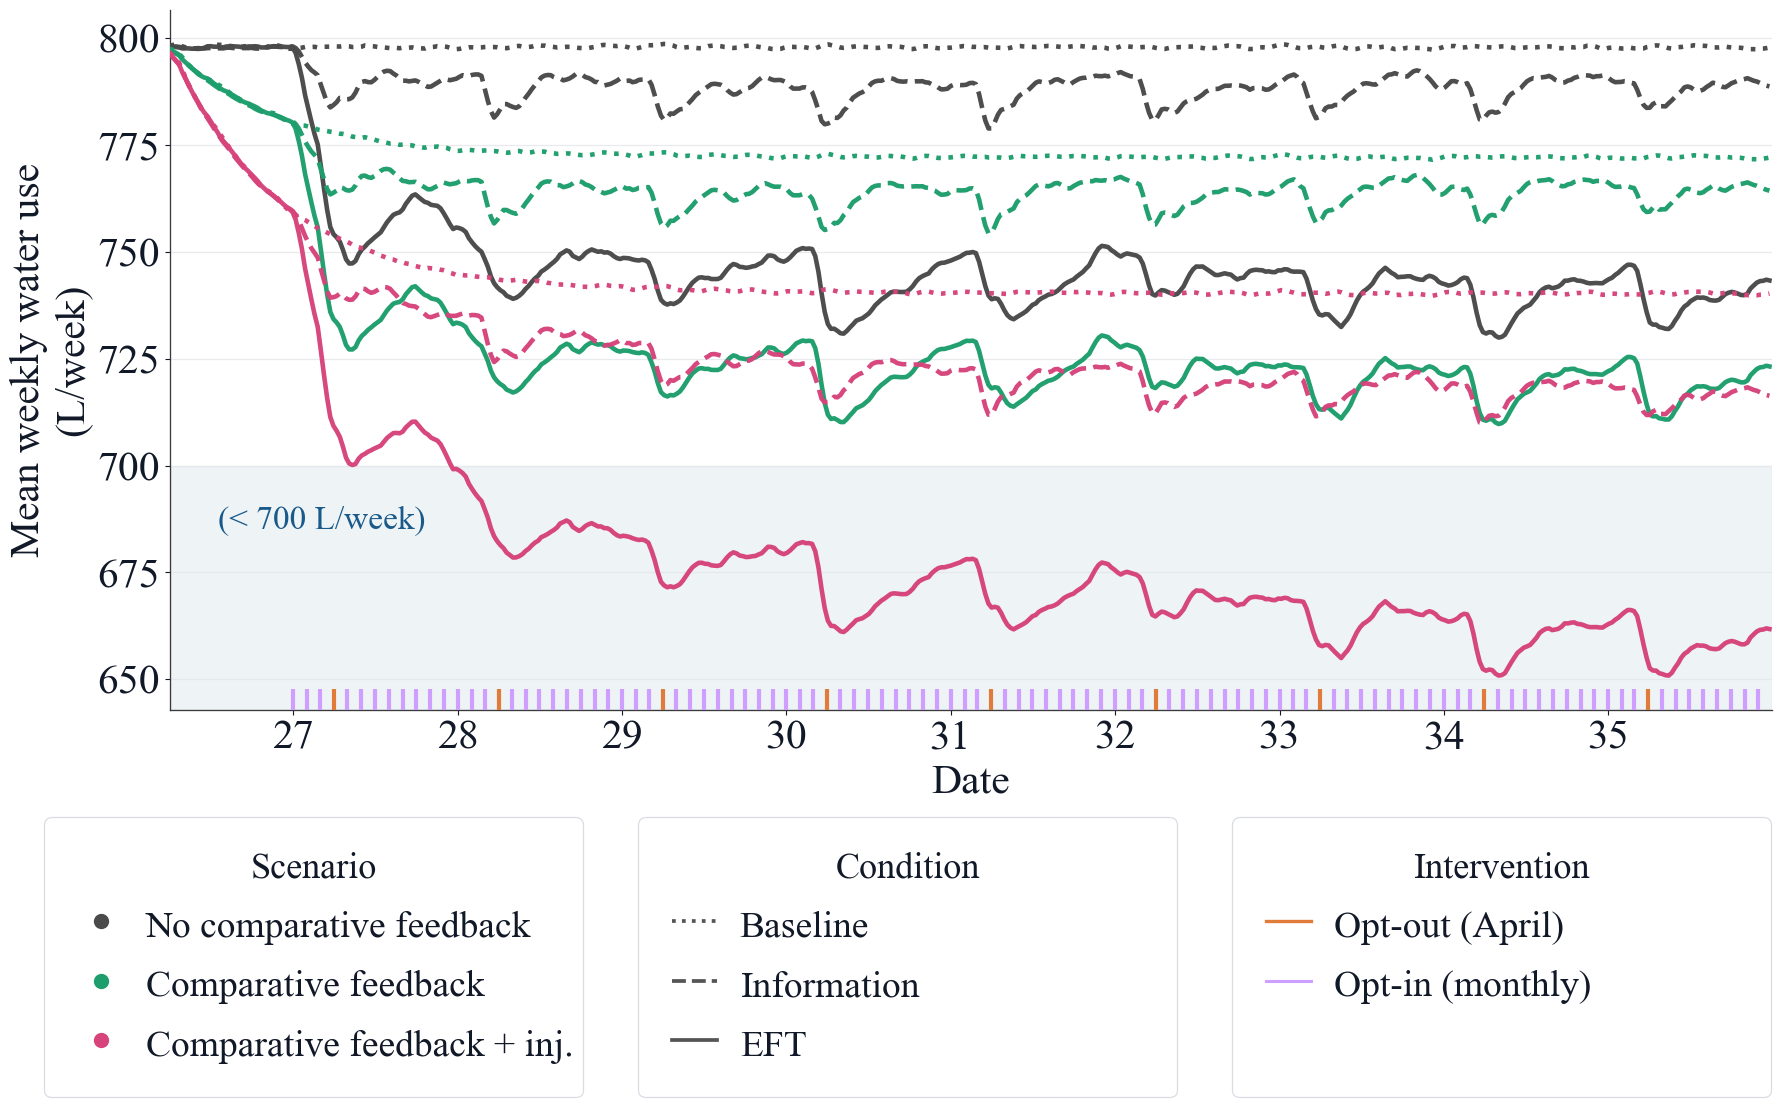

In [44]:
ConditionLineStyles = {
    "baseline": ":",
    "information": "--", 
    "eft": "-",
}

mpl.rcParams.update({
    "font.size":        30,
    "axes.labelsize":   30,
    "axes.titlesize":   30,
    "xtick.labelsize":  30,
    "ytick.labelsize":  30,
})

Plot2FigureWidth  = 18
Plot2FigureHeight = 14.0
LegendFS          = 27    
LegendTitleFS     = 26     

def FormatYearAxis(ax):
    """PascalCase-alias voor format_year_axis (zelfde stijl als plot 1)."""
    format_year_axis(ax)

def ApplyThesisStyle(ax):
    """PascalCase-alias voor apply_thesis_style (zelfde stijl als plot 1)."""
    apply_thesis_style(ax)

def AddTargetArea(ax, y_min, label=True):
    """Vul het gebied tussen de onderkant van de y-as en de targetlijn,
    zodat 'onder het doel' visueel duidelijk is (in plaats van alleen
    een streepjeslijn zoals add_target_line doet)."""
    ax.axhspan(
        y_min, WaterTarget,
        color="#1a5a8a",
        alpha=0.07,
        zorder=0,
    )

def StyleLegendFrame(legend):
    """Geef een Figure.legend() hetzelfde witte kader met grijze rand
    als de legenda onder plot 1."""
    frame = legend.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("#D0D5DD")
    frame.set_linewidth(0.9)
    return legend

ScenarioColorsOverview = ScenarioColors

ConditionLabels = {
    "baseline": "Baseline",
    "information": "Information",
    "eft": "EFT",
}

AllYValues = []
for ScenarioName in ScenarioOrder:
    for Condition in ConditionOrder:
        SmoothedWater = (
            ScenarioResults[(ScenarioName, Condition)]["mean_water"]
            .rolling(4, min_periods=1).mean()
        )
        AllYValues.extend(SmoothedWater.tolist())

YMinPlot = min(min(AllYValues) - 8, WaterTarget - 12)
YMaxPlot = max(max(AllYValues) + 8, WaterTarget + 12)

Figure, Axis = plt.subplots(figsize=(Plot2FigureWidth, Plot2FigureHeight))
Figure.subplots_adjust(bottom=0.38, top=0.88, left=0.09, right=0.98)

AddTargetArea(Axis, YMinPlot, label=False)

Axis.text(
    0.03, 0.25,
    f"(< {WaterTarget:.0f} L/week)",
    transform=Axis.transAxes,
    fontsize=24,
    color="#1a5a8a",
    ha="left", va="bottom",
    zorder=5,
)

for ScenarioName in ScenarioOrder:
    for Condition in ConditionOrder:
        DataForLine = ScenarioResults[(ScenarioName, Condition)]
        SmoothedWater = DataForLine["mean_water"].rolling(4, min_periods=1).mean()
        Axis.plot(
            DataForLine["date"], SmoothedWater,
            color=ScenarioColorsOverview[ScenarioName],
            linestyle=ConditionLineStyles[Condition],  # << gebruikt nieuwe stijlen
            linewidth=3.3,
            alpha=0.98, zorder=3,
        )

Axis.set_xlim(StartDateOfSimulation, EndDateOfSimulation)
Axis.set_ylim(YMinPlot, YMaxPlot)
Axis.margins(x=0.01)
FormatYearAxis(Axis)
ApplyThesisStyle(Axis)
Axis.tick_params(axis="both", which="major", labelsize=38)
InterventionStartDate = FirstDateOfIntervention

# Kleuren voor interventies
OptOutColor = "#e07b39"
OptInColor  = "#CF9FFF"

InterventionDates = pd.date_range(
    InterventionStartDate,
    EndDateOfSimulation,
    freq="MS",
)

for d in InterventionDates:
    if d.month == 4:
        Axis.vlines(
            d, 0.0, 0.03,
            transform=Axis.get_xaxis_transform(),
            color=OptOutColor,
            linewidth=3,
            linestyle="-",
            zorder=6,
            clip_on=False,
        )
    else:
        Axis.vlines(
            d, 0.0, 0.03,
            transform=Axis.get_xaxis_transform(),
            color=OptInColor,
            linewidth=3.0,
            linestyle="-",
            zorder=5,
            clip_on=False,
        )

Axis.set_xlabel("Date", fontsize=30)
Axis.set_ylabel("Mean weekly water use\n(L/week)", fontsize=30)
Axis.tick_params(axis="both", which="major", labelsize=30)

# legend

ScenarioHandles = []
for s in ScenarioOrder:
    label = s.replace("injunctive", "inj.")
    ScenarioHandles.append(
        mlines.Line2D(
            [], [],
            color=ScenarioColorsOverview[s],
            linestyle="None",
            marker="o",
            markersize=10,
            label=label,
        )
    )

ConditionHandles = [
    mlines.Line2D(
        [], [], color="#555555", linewidth=2.7,
        linestyle=ConditionLineStyles[c], label=ConditionLabels[c]
    )
    for c in ConditionOrder
]

InterventionHandles = [
    mlines.Line2D(
        [], [], color=OptOutColor, linewidth=2.4,
        linestyle="-",
        label="Opt-out (April)"
    ),
    mlines.Line2D(
        [], [], color=OptInColor, linewidth=2.2,
        linestyle="-",
        label="Opt-in (monthly)"
    ),
    mlines.Line2D(
        [], [], color=(0, 0, 0, 0), linewidth=0,
        label=" "
    ),
]

legend_kwargs = dict(
    frameon=True,
    ncol=1,
    handlelength=1.2,
    handleheight=1.1,
    handletextpad=0.6,
    labelspacing=0.55,
    borderpad=0.9,
    fontsize=LegendFS,
    title_fontsize=LegendTitleFS,
)

y0 = 0.09 

leg1 = Figure.legend(
    handles=ScenarioHandles,
    title="Scenario",
    loc="lower left",
    bbox_to_anchor=(0.01, y0, 0.32, 0.27),
    bbox_transform=Figure.transFigure,
    mode="expand",
    **legend_kwargs,
)
StyleLegendFrame(leg1)

leg2 = Figure.legend(
    handles=ConditionHandles,
    title="Condition",
    loc="lower left",
    bbox_to_anchor=(0.34, y0, 0.32, 0.27),
    bbox_transform=Figure.transFigure,
    mode="expand",
    **legend_kwargs,
)
StyleLegendFrame(leg2)

leg3 = Figure.legend(
    handles=InterventionHandles,
    title="Intervention",
    loc="lower left",
    bbox_to_anchor=(0.67, y0, 0.32, 0.27),
    bbox_transform=Figure.transFigure,
    mode="expand",
    **legend_kwargs,
)
StyleLegendFrame(leg3)

plt.show()

In [45]:
# ABM outcome table

FinalYearRows = []

for (ScenarioName, Condition), Results in ScenarioResults.items():
    FinalYear = Results[Results["date"].dt.year == 2035]
    MeanWater = FinalYear["mean_water"].mean()
    FinalYearRows.append({
        "Social-feedback scenario": ScenarioName,
        "Condition": Condition.capitalize(),
        "Mean water use (L/week)": round(MeanWater, 1),
        "Target reached": "Yes" if MeanWater < WaterTarget else "No"
    })

ABMOutcomeTable = pd.DataFrame(FinalYearRows)
ConditionOrder2 = ["Baseline", "Information", "Eft"]
ABMOutcomeTable["Condition"] = pd.Categorical(ABMOutcomeTable["Condition"], categories=ConditionOrder2, ordered=True)
ABMOutcomeTable["Social-feedback scenario"] = pd.Categorical(ABMOutcomeTable["Social-feedback scenario"], categories=ScenarioOrder, ordered=True)
ABMOutcomeTable = ABMOutcomeTable.sort_values(["Social-feedback scenario", "Condition"]).reset_index(drop=True)

ABMOutcomeTable

,Social-feedback scenario,Condition,Mean water use (L/week),Target reached
0,No comparative feedback,Baseline,797.8,No
1,No comparative feedback,Information,788.1,No
2,No comparative feedback,Eft,739.7,No
3,Comparative feedback,Baseline,772.1,No
4,Comparative feedback,Information,763.8,No
5,Comparative feedback,Eft,718.8,No
6,Comparative feedback + injunctive,Baseline,740.3,No
7,Comparative feedback + injunctive,Information,716.0,No
8,Comparative feedback + injunctive,Eft,658.4,Yes


### Plot 3: boomerang sensitivity

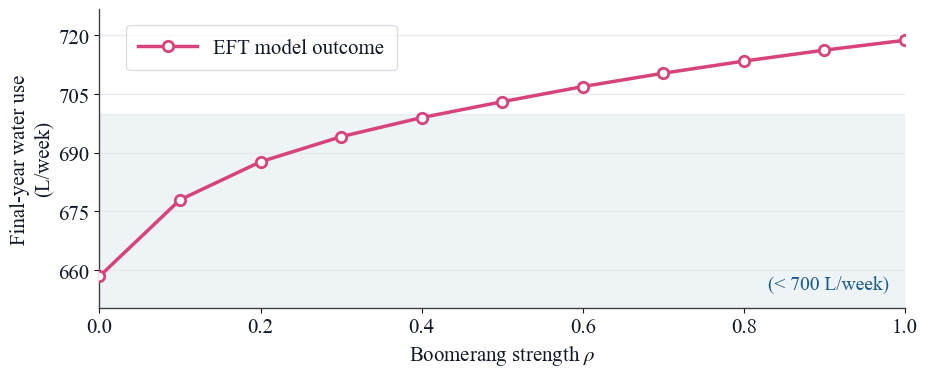

,boomerang_rho,mean_water_final_year,distance_to_target,reaches_target
0,0.0,658.38,-41.62,True
1,0.1,677.97,-22.03,True
2,0.2,687.70,-12.30,True
3,0.3,694.11,-5.89,True
4,0.4,698.99,-1.01,True
5,0.5,703.05,3.05,False
6,0.6,706.92,6.92,False
7,0.7,710.35,10.35,False
8,0.8,713.44,13.44,False
9,0.9,716.24,16.24,False


In [46]:
def SaveFigure(base_name):
    save_figure(base_name)


def AddStyledLegend(ax, **legend_kwargs):
    legend = ax.legend(**legend_kwargs)
    frame = legend.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("#D0D5DD")
    frame.set_linewidth(0.9)
    return legend

# Colors chosen
ConditionColors = {
    "baseline": "#4A4A4A",
    "information": "#1a5a8a",
    "eft": "#D6447B",
}

TargetAreaColor = "#1a5a8a"

# layout
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

Plot3FigureWidth = 9.5
Plot3FigureHeight = 4.0

FinalWindowWeeks = 52
BoomerangValues = np.linspace(0, 1, 11)

BoomerangRecords = []

for RhoValue in BoomerangValues:
    Output = RunModel( Condition="eft",KeepAgents=False,PhiValues=AgentPhi,AdoptersMask=AppAdopter,RhoValue=RhoValue,)
    FinalWeeks = Output.tail(FinalWindowWeeks)
    MeanWater = FinalWeeks["mean_water"].mean()

    BoomerangRecords.append({"boomerang_rho": RhoValue,"mean_water_final_year": MeanWater,"distance_to_target": MeanWater - WaterTarget,
    "reaches_target": MeanWater <= WaterTarget,})

BoomerangResults = pd.DataFrame(BoomerangRecords)

Figure, Axis = plt.subplots(figsize=(Plot3FigureWidth, Plot3FigureHeight))

Axis.set_xlabel("Boomerang strength $\\rho$", fontsize=15)
Axis.set_ylabel("Final-year water use\n(L/week)", fontsize=15)

YMinBoomerang = min(
    BoomerangResults["mean_water_final_year"].min(),
    WaterTarget,
) - 8

YMaxBoomerang = max(
    BoomerangResults["mean_water_final_year"].max(),
    WaterTarget,
) + 8

# main line
Axis.plot(
    BoomerangResults["boomerang_rho"],
    BoomerangResults["mean_water_final_year"],
    color=ConditionColors["eft"],
    marker="o",
    markerfacecolor="white",
    markeredgecolor=ConditionColors["eft"],
    markeredgewidth=2.0,
    linewidth=2.5,
    markersize=7.5,
    label="EFT model outcome",
    zorder=4,
)

# Blue target-area
Axis.axhspan(
    YMinBoomerang,
    WaterTarget,
    color=TargetAreaColor,
    alpha=0.07,
    zorder=0,
)

Axis.set_xlim(BoomerangValues.min(), BoomerangValues.max())
Axis.set_ylim(YMinBoomerang, YMaxBoomerang)
Axis.xaxis.set_major_locator(MaxNLocator(nbins=6))
Axis.yaxis.set_major_locator(MaxNLocator(nbins=6))

ApplyThesisStyle(Axis)
Axis.tick_params(axis="both", which="major", labelsize=15)  # of 12, 14, ...

Axis.set_xlabel("Boomerang strength $\\rho$")
Axis.set_ylabel("Final-year water use\n(L/week)")

# legend

Plot3Legend = AddStyledLegend(
    Axis,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    frameon=True,
    handlelength=2.8,
    labelspacing=0.6,
    borderpad=0.6,
    fontsize=15,
)


# Target reached area

Axis.text(
    0.98, 0.05,
    f"\n(< {WaterTarget:.0f} L/week)",
    transform=Axis.transAxes,
    color="#1a5a8a",
    fontsize=14,
    ha="right",
    va="bottom",
)

plt.tight_layout()
SaveFigure("plot_3_boomerang_sensitivity_thesis")
plt.show()

display(BoomerangResults.round(2))

## 9. Sensitivity analysis

Each parameter is varied across five values (low → high). The outcome is the
mean weekly water use over the final 52 weeks of the simulation (year 2035),
evaluated for the EFT condition. Parameters are ranked by their maximum range
across scenarios.


In [47]:
FinalPointCondition = "eft"
FinalWindowWeeks = 52
SensitivityScenarios = ScenarioOrder


@contextlib.contextmanager
def TemporaryGlobals(**Patch):
    """Temporarily change model values, then put the old values back."""
    OldValues = {Name: globals()[Name] for Name in Patch}
    try:
        globals().update(Patch)
        yield
    finally:
        globals().update(OldValues)


def EndpointMetric(Condition, PhiValues, AdoptersMask, RhoValue):
    """Run the model once and return the final-window water use."""
    Output = RunModel(Condition, KeepAgents=False, PhiValues=PhiValues, AdoptersMask=AdoptersMask, RhoValue=RhoValue)
    LastWeeks = Output.tail(FinalWindowWeeks)
    MeanWater = float(LastWeeks["mean_water"].mean())

    return {
        "endpoint_mean_water": MeanWater, "endpoint_sd": float(LastWeeks["mean_water"].std()), "endpoint_min": float(LastWeeks["mean_water"].min()),
        "endpoint_max": float(LastWeeks["mean_water"].max()), "distance_to_target": MeanWater - WaterTarget,}

def RecalculateBaselineWater(Patch):
    """Patch water-use parameters and also update baseline water use."""
    OldValues = {Name: globals()[Name] for Name in Patch}
    globals().update(Patch)

    if any(Name in Patch for Name in ["StandardShowerFlow", "SavingShowerFlow", "RainShowerFlow"]):
        Agents["FlowRate"] = Agents["Showerhead"].apply(FlowRate)

    NewBaselineWater = WeeklyWater(BaselineIntentions)

    globals().update(OldValues)
    Agents["FlowRate"] = Agents["Showerhead"].apply(FlowRate)

    FullPatch = dict(Patch)
    FullPatch["BaselineWater"] = NewBaselineWater
    return FullPatch

def CurrentSocialSettings(ScenarioName):
    Settings = SocialScenarios[ScenarioName]
    return Settings["phi"].copy(), Settings["adopters"].copy(), float(Settings["rho"])

def SocialKeepCurrent(Value, ScenarioName):
    return CurrentSocialSettings(ScenarioName)

def SocialFeedbackMultiplier(Value, ScenarioName):
    PhiValues, Adopters, RhoValue = CurrentSocialSettings(ScenarioName)
    if ScenarioName == "No comparative feedback":
        return np.zeros(NumberOfAgents), np.zeros(NumberOfAgents, dtype=bool), RhoValue
    return PhiValues * Value, Adopters, RhoValue

AdoptionDrawsSensitivity = np.random.default_rng(Seed + 900).random(NumberOfAgents)

def SocialAppAdoption(Value, ScenarioName):
    PhiValues, Adopters, RhoValue = CurrentSocialSettings(ScenarioName)
    if ScenarioName == "No comparative feedback":
        return np.zeros(NumberOfAgents), np.zeros(NumberOfAgents, dtype=bool), RhoValue

    NewAdopters = AdoptionDrawsSensitivity < Value
    NewPhi = np.where(NewAdopters, Responsiveness * Phi, 0.0)
    return NewPhi, NewAdopters, RhoValue

def MakeResponsiveness(NonResponderValue=None, SdValue=None):
    NonResponderValue = NonResponderShare if NonResponderValue is None else NonResponderValue
    SdValue = SdResponder if SdValue is None else SdValue

    TemporaryResponders = DrawTruncatedNormal(
        1 / (1 - NonResponderValue), SdValue, 0.0, np.inf, NumberOfAgents, np.random.default_rng(Seed + 901), )
    TemporaryNonResponders = np.random.default_rng(Seed + 902).random(NumberOfAgents) < NonResponderValue
    return np.where(TemporaryNonResponders, 0.0, TemporaryResponders)

def SocialNonResponderShare(Value, ScenarioName):
    PhiValues, Adopters, RhoValue = CurrentSocialSettings(ScenarioName)

    if ScenarioName == "No comparative feedback":
        return np.zeros(NumberOfAgents), np.zeros(NumberOfAgents, dtype=bool), RhoValue

    TemporaryResponsiveness = MakeResponsiveness(NonResponderValue=Value)
    NewPhi = np.where(Adopters, TemporaryResponsiveness * Phi, 0.0)
    return NewPhi, Adopters, RhoValue

def SocialResponsivenessSd(Value, ScenarioName):
    PhiValues, Adopters, RhoValue = CurrentSocialSettings(ScenarioName)

    if ScenarioName == "No comparative feedback":
        return np.zeros(NumberOfAgents), np.zeros(NumberOfAgents, dtype=bool), RhoValue

    TemporaryResponsiveness = MakeResponsiveness(SdValue=Value)
    NewPhi = np.where(Adopters, TemporaryResponsiveness * Phi, 0.0)
    return NewPhi, Adopters, RhoValue

def ScaleGamma(Value):
    return {Behaviour: Gamma[Behaviour] * Value for Behaviour in Gamma}

def SensitivitySpec(Parameter, Description, Values, SocialFunction=SocialKeepCurrent, PatchFunction=None):
    return {"parameter": Parameter, "description": Description, "values": Values, "social_function": SocialFunction,
            "patch_function": PatchFunction, }

################################### Sensitivity Paramters #####################################
SensitivityParameters = [

    # alpha_IB = 0.50: meta-analytic average from Sheeran & Gollwitzer (2015).
    # Min 0.25: pessimistic scenario where little intention translates to behaviour.
    # 0.35: lower bound of the plausible range around the average.
    # 0.50: central estimate.
    # 0.65: upper bound of the plausible range around the average.
    # Max 0.75: optimistic scenario where most intention translates to behaviour.
    SensitivitySpec("alpha_IB", "Intention-behaviour translation factor", [0.25, 0.35, 0.50, 0.65, 0.75],
                    PatchFunction=lambda Value: {"AlphaIB": Value}),

    
    # social_feedback_strength = 1.00: baseline multiplier on phi (no adjustment).
    # Min 0.00: tests what happens if social comparison has no effect at all.
    # 0.50: tests a weakened social comparison effect.
    # 1.00: calibrated value based on Ferraro & Price (2013) and Brent et al. (2015).
    # 1.50: tests a moderately stronger effect than calibrated.
    # Max 2.00: tests what happens if the effect is twice as strong as calibrated.
    SensitivitySpec("social_feedback_strength", "Multiplier on social feedback strength phi", [0.00, 0.50, 1.00, 1.50, 2.00],
                    SocialFunction=SocialFeedbackMultiplier),

    # app_adoption_probability = 0.78: Koop et al. (2021), Dutch sample.
    # Min 0.25: conservative scenario where adoption is much lower than expected.
    # 0.50: scenario where only half of agents adopt the app.
    # 0.78: empirical estimate from Koop et al. (2021).
    # 0.90: optimistic scenario with near-complete adoption.
    # Max 1.00: theoretical maximum where every agent adopts the app.
    SensitivitySpec("app_adoption_probability", "Probability that an agent adopts the app", [0.25, 0.50, 0.78, 0.90, 1.00],
                    SocialFunction=SocialAppAdoption),

    # tau_max_EFT = 180 days (~6 months): model assumption from the formula sheet.
    # Min 60 days (~2 months): pessimistic scenario, EFT effects decay quickly.
    # 120 days (~4 months): lower sensitivity bound.
    # 180 days (~6 months): central model assumption.
    # 240 days (~8 months): upper sensitivity bound.
    # Max 360 days (~12 months): optimistic scenario, EFT effects are highly durable.
    SensitivitySpec("tau_max_EFT", "Maximum EFT decay constant", [60, 120, 180, 240, 360],
                    PatchFunction=lambda Value: {"TauMaxEft": Value}),

    # tau0_EFT = 25 days: based on Duan et al. (2025) average of
    # information decay (13 days) and feedback decay (12 days), doubled
    # to reflect the stronger memory encoding of EFT (Schacter, 2012).
    # Min 12.5 days: the undoubled base estimate from Duan et al.
    # 18 days: intermediate between the undoubled base and the central estimate.
    # 25 days: central model assumption.
    # 37.5 days: 1.5x the central estimate, moderately optimistic.
    # Max 50 days: double the central estimate, upper bound.
    SensitivitySpec("tau0_EFT", "Initial EFT decay constant", [12.5, 18, 25, 37.5, 50],
                    PatchFunction=lambda Value: {"Tau0Eft": Value}),

    # mu_EFT = 0.40: model assumption without direct empirical basis.
    # Min 0.10: very slow growth of tau per session.
    # 0.20: slower growth, effect builds up more gradually.
    # 0.40: central model assumption.
    # 0.60: faster growth, effect builds up more quickly.
    # Max 0.80: very fast growth, tau approaches ceiling after few sessions.
    SensitivitySpec("mu_EFT", "Growth rate of EFT decay constant", [0.10, 0.20, 0.40, 0.60, 0.80],
                    PatchFunction=lambda Value: {"MuEft": Value}),

    # tau_max_info = 30 days: model assumption, substantially lower than EFT
    # ceiling because information produces weaker memory encoding.
    # Min 15 days: pessimistic scenario, information effects decay quickly.
    # 20 days: lower sensitivity bound.
    # 30 days: central model assumption.
    # 45 days: upper sensitivity bound.
    # Max 60 days: optimistic scenario approaching the lower EFT range.
    SensitivitySpec("tau_max_info", "Maximum information decay constant", [15, 20, 30, 45, 60],
                    PatchFunction=lambda Value: {"TauMaxInfo": Value}),

    # tau0_info = 13 days: taken directly from Duan et al. (2025), Table 2.
    # Min 5 days: pessimistic scenario, very rapid initial decay.
    # 7 days: approximately half the empirical estimate.
    # 13 days: central empirical estimate from Duan et al. (2025).
    # 19 days: intermediate between the central estimate and the EFT value.
    # Max 25 days: equal to tau0_EFT, upper bound where information
    # is as durable as the conservative EFT estimate.
    SensitivitySpec("tau0_info", "Initial information decay constant", [5, 7, 13, 19, 25],
                    PatchFunction=lambda Value: {"Tau0Info": Value}),

    # mu_info = 0.40: model assumption, set equal to mu_EFT for comparability.
    # Min 0.10: very slow build-up, information effect grows little per session.
    # 0.20: slower build-up than the central estimate.
    # 0.40: central model assumption.
    # 0.60: faster build-up, equal to the EFT upper bound.
    # Max 0.80: very fast build-up, tau approaches ceiling after few sessions.
    SensitivitySpec("mu_info", "Growth rate of information decay constant", [0.10, 0.20, 0.40, 0.60, 0.80],
                    PatchFunction=lambda Value: {"MuInfo": Value}),

    # lnk_pathway_strength = 1.00: baseline multiplier on gamma (no adjustment).
    # Min 0.00: ln(k) pathway completely absent; only residual EFT effect remains.
    # 0.50: pathway is half as strong as calibrated.
    # 1.00: calibrated value based on R² estimate of p.
    # 1.50: pathway is moderately stronger than calibrated.
    # Max 2.00: pathway is twice as strong as calibrated.
    SensitivitySpec("lnk_pathway_strength", "Multiplier on gamma: ln(k) to intention pathway", [0.00, 0.50, 1.00, 1.50, 2.00],
                    PatchFunction=lambda Value: {"Gamma": ScaleGamma(Value)}),

    # DeltaEFT = 2.8: calibrated on session-by-session results of Mellis et al. (2019).
    # Min 0.70: quarter of the calibrated value, strongly pessimistic scenario.
    # 1.40: half of the calibrated value, pessimistic scenario.
    # 2.80: central calibrated value.
    # 4.20: one and a half times the calibrated value, optimistic scenario.
    # Max 5.60: double the calibrated value, strongly optimistic scenario.
    SensitivitySpec("DeltaEFT", "Maximum EFT reduction in ln(k)", [0.70, 1.40, 2.80, 4.20, 5.60],
                    PatchFunction=lambda Value: {"DeltaEFT": Value}),

    # lambda_EFT = 0.55: calibrated on Mellis et al. (2019).
    # Min 0.10: very slow saturation, effect builds up gradually across many sessions.
    # 0.25: slower saturation than the central estimate.
    # 0.55: central calibrated value.
    # 0.70: faster saturation, effect reaches ceiling after fewer sessions.
    # Max 0.85: rapid saturation, most of the effect occurs in the first session.
    SensitivitySpec("lambda_EFT", "Saturation rate of EFT effect", [0.10, 0.25, 0.55, 0.70, 0.85],
                    PatchFunction=lambda Value: {"LambdaEFT": Value}),

    # nonresponder_share_P0 = 0.561: Otaki et al. (2024), share of households
    # showing no meaningful behavioural change after social comparison feedback.
    # Min 0.25: optimistic scenario where most people respond.
    # 0.35: lower sensitivity bound.
    # 0.561: central empirical estimate from Otaki et al. (2024).
    # 0.70: pessimistic scenario where the majority does not respond.
    # Max 0.85: strongly pessimistic scenario with very few responders.
    SensitivitySpec("nonresponder_share_P0", "Share of app adopters who do not respond", [0.25, 0.35, 0.561, 0.70, 0.85],
                    SocialFunction=SocialNonResponderShare),

    # social_responsiveness_sigma = 0.50: model assumption without direct empirical basis.
    # Min 0.10: very little spread, responders are nearly uniform in response strength.
    # 0.25: less spread than the central estimate.
    # 0.50: central model assumption.
    # 0.75: more spread, stronger heterogeneity in response strength.
    # Max 1.00: high heterogeneity, large variation in individual responsiveness.
    SensitivitySpec("social_responsiveness_sigma", "Spread in social responsiveness", [0.10, 0.25, 0.50, 0.75, 1.00],
                    SocialFunction=SocialResponsivenessSd),

    # voluntary_monthly_participation = 0.20: opt-in participation rate from
    # Fowlie et al. (2021), where ~20% of households actively enrolled.
    # Min 0.05: strongly pessimistic scenario with very low voluntary participation.
    # 0.10: pessimistic scenario with half the expected participation.
    # 0.20: central empirical estimate from Fowlie et al. (2021).
    # 0.30: moderately optimistic scenario.
    # Max 0.40: optimistic scenario with double the expected participation.
    SensitivitySpec("voluntary_monthly_participation", "Monthly voluntary intervention participation probability",
                    [0.05, 0.10, 0.20, 0.30, 0.40],
                    PatchFunction=lambda Value: {"MonthlyOptIn": Value}),

    # april_intervention_participation = 0.95: opt-out participation rate from
    # Fowlie et al. (2021), where fewer than 5% opted out when defaulted in.
    # Min 0.65: strongly pessimistic scenario with substantial opt-out.
    # 0.75: pessimistic scenario where more people drop out.
    # 0.95: central empirical estimate from Fowlie et al. (2021).
    # 0.98: near-complete participation, slightly above central estimate.
    # Max 1.00: theoretical maximum where nobody opts out.
    SensitivitySpec("april_intervention_participation", "Annual April intervention participation probability",
                    [0.65, 0.75, 0.95, 0.98, 1.00],
                    PatchFunction=lambda Value: {"YearlyOptOutApril": Value}),
]

SensitivityRecords = []

for Item in SensitivityParameters:
    for Value in Item["values"]:
        Patch = Item["patch_function"](Value) if Item["patch_function"] else {}

        with TemporaryGlobals(**Patch):
            for ScenarioName in SensitivityScenarios:
                PhiValues, Adopters, RhoValue = Item["social_function"](Value, ScenarioName)
                SensitivityRecords.append({"parameter": Item["parameter"],
                    "description": Item["description"], "value": Value,
                    "scenario": ScenarioName, "condition": FinalPointCondition,
                    **EndpointMetric(FinalPointCondition, PhiValues, Adopters, RhoValue), })

SensitivityScreeningRaw = pd.DataFrame(SensitivityRecords)

ScenarioRanges = (
    SensitivityScreeningRaw
    .groupby(["parameter", "description", "scenario"])["endpoint_mean_water"]
    .agg(["min", "max"])
    .reset_index())
ScenarioRanges["range_L_per_week"] = ScenarioRanges["max"] - ScenarioRanges["min"]

SensitivityRankingTable = (
    ScenarioRanges
    .pivot_table(index=["parameter", "description"], columns="scenario", values="range_L_per_week", aggfunc="max")
    .reset_index())

ScenarioColumns = [Column for Column in SensitivityRankingTable.columns if Column not in ["parameter", "description"]]
SensitivityRankingTable["max_sensitivity_range_L_week"] = SensitivityRankingTable[ScenarioColumns].max(axis=1)
SensitivityRankingTable["mean_sensitivity_range_L_week"] = SensitivityRankingTable[ScenarioColumns].mean(axis=1)
SensitivityRankingTable = SensitivityRankingTable.sort_values("max_sensitivity_range_L_week", ascending=False).reset_index(drop=True)
SensitivityRankingTable["rank"] = np.arange(1, len(SensitivityRankingTable) + 1)
SensitivityRankingTable = SensitivityRankingTable[["rank", "parameter", "description", "max_sensitivity_range_L_week", "mean_sensitivity_range_L_week"] + ScenarioColumns]

display(SensitivityRankingTable.round(2))

scenario,rank,parameter,description,max_sensitivity_range_L_week,mean_sensitivity_range_L_week,Comparative feedback,Comparative feedback + injunctive,No comparative feedback
0,1,nonresponder_share_P0,Share of app adopters who do not respond,122.24,53.30,37.67,122.24,0.00
1,2,social_feedback_strength,Multiplier on social feedback strength phi,89.21,38.46,26.17,89.21,0.00
2,3,app_adoption_probability,Probability that an agent adopts the app,83.34,34.40,19.86,83.34,0.00
3,4,alpha_IB,Intention-behaviour translation factor,69.21,60.23,53.10,69.21,58.37
4,5,tau_max_EFT,Maximum EFT decay constant,42.57,40.66,42.57,39.98,39.43
5,6,voluntary_monthly_participation,Monthly voluntary intervention participation p...,39.44,36.26,39.44,35.34,34.01
6,7,mu_EFT,Growth rate of EFT decay constant,5.65,3.18,5.65,1.71,2.17
7,8,april_intervention_participation,Annual April intervention participation probab...,3.81,3.29,3.81,2.97,3.07
8,9,social_responsiveness_sigma,Spread in social responsiveness,2.92,1.32,1.05,2.92,0.00
9,10,tau0_EFT,Initial EFT decay constant,0.41,0.18,0.41,0.12,0.00


## 10. Plot top sensitivity results

The five most influential parameters are plotted for each social-feedback scenario.
The x-axis runs from the lowest to the highest tested value (normalised to [0,1]).
The dashed line marks the 700 L/week target.


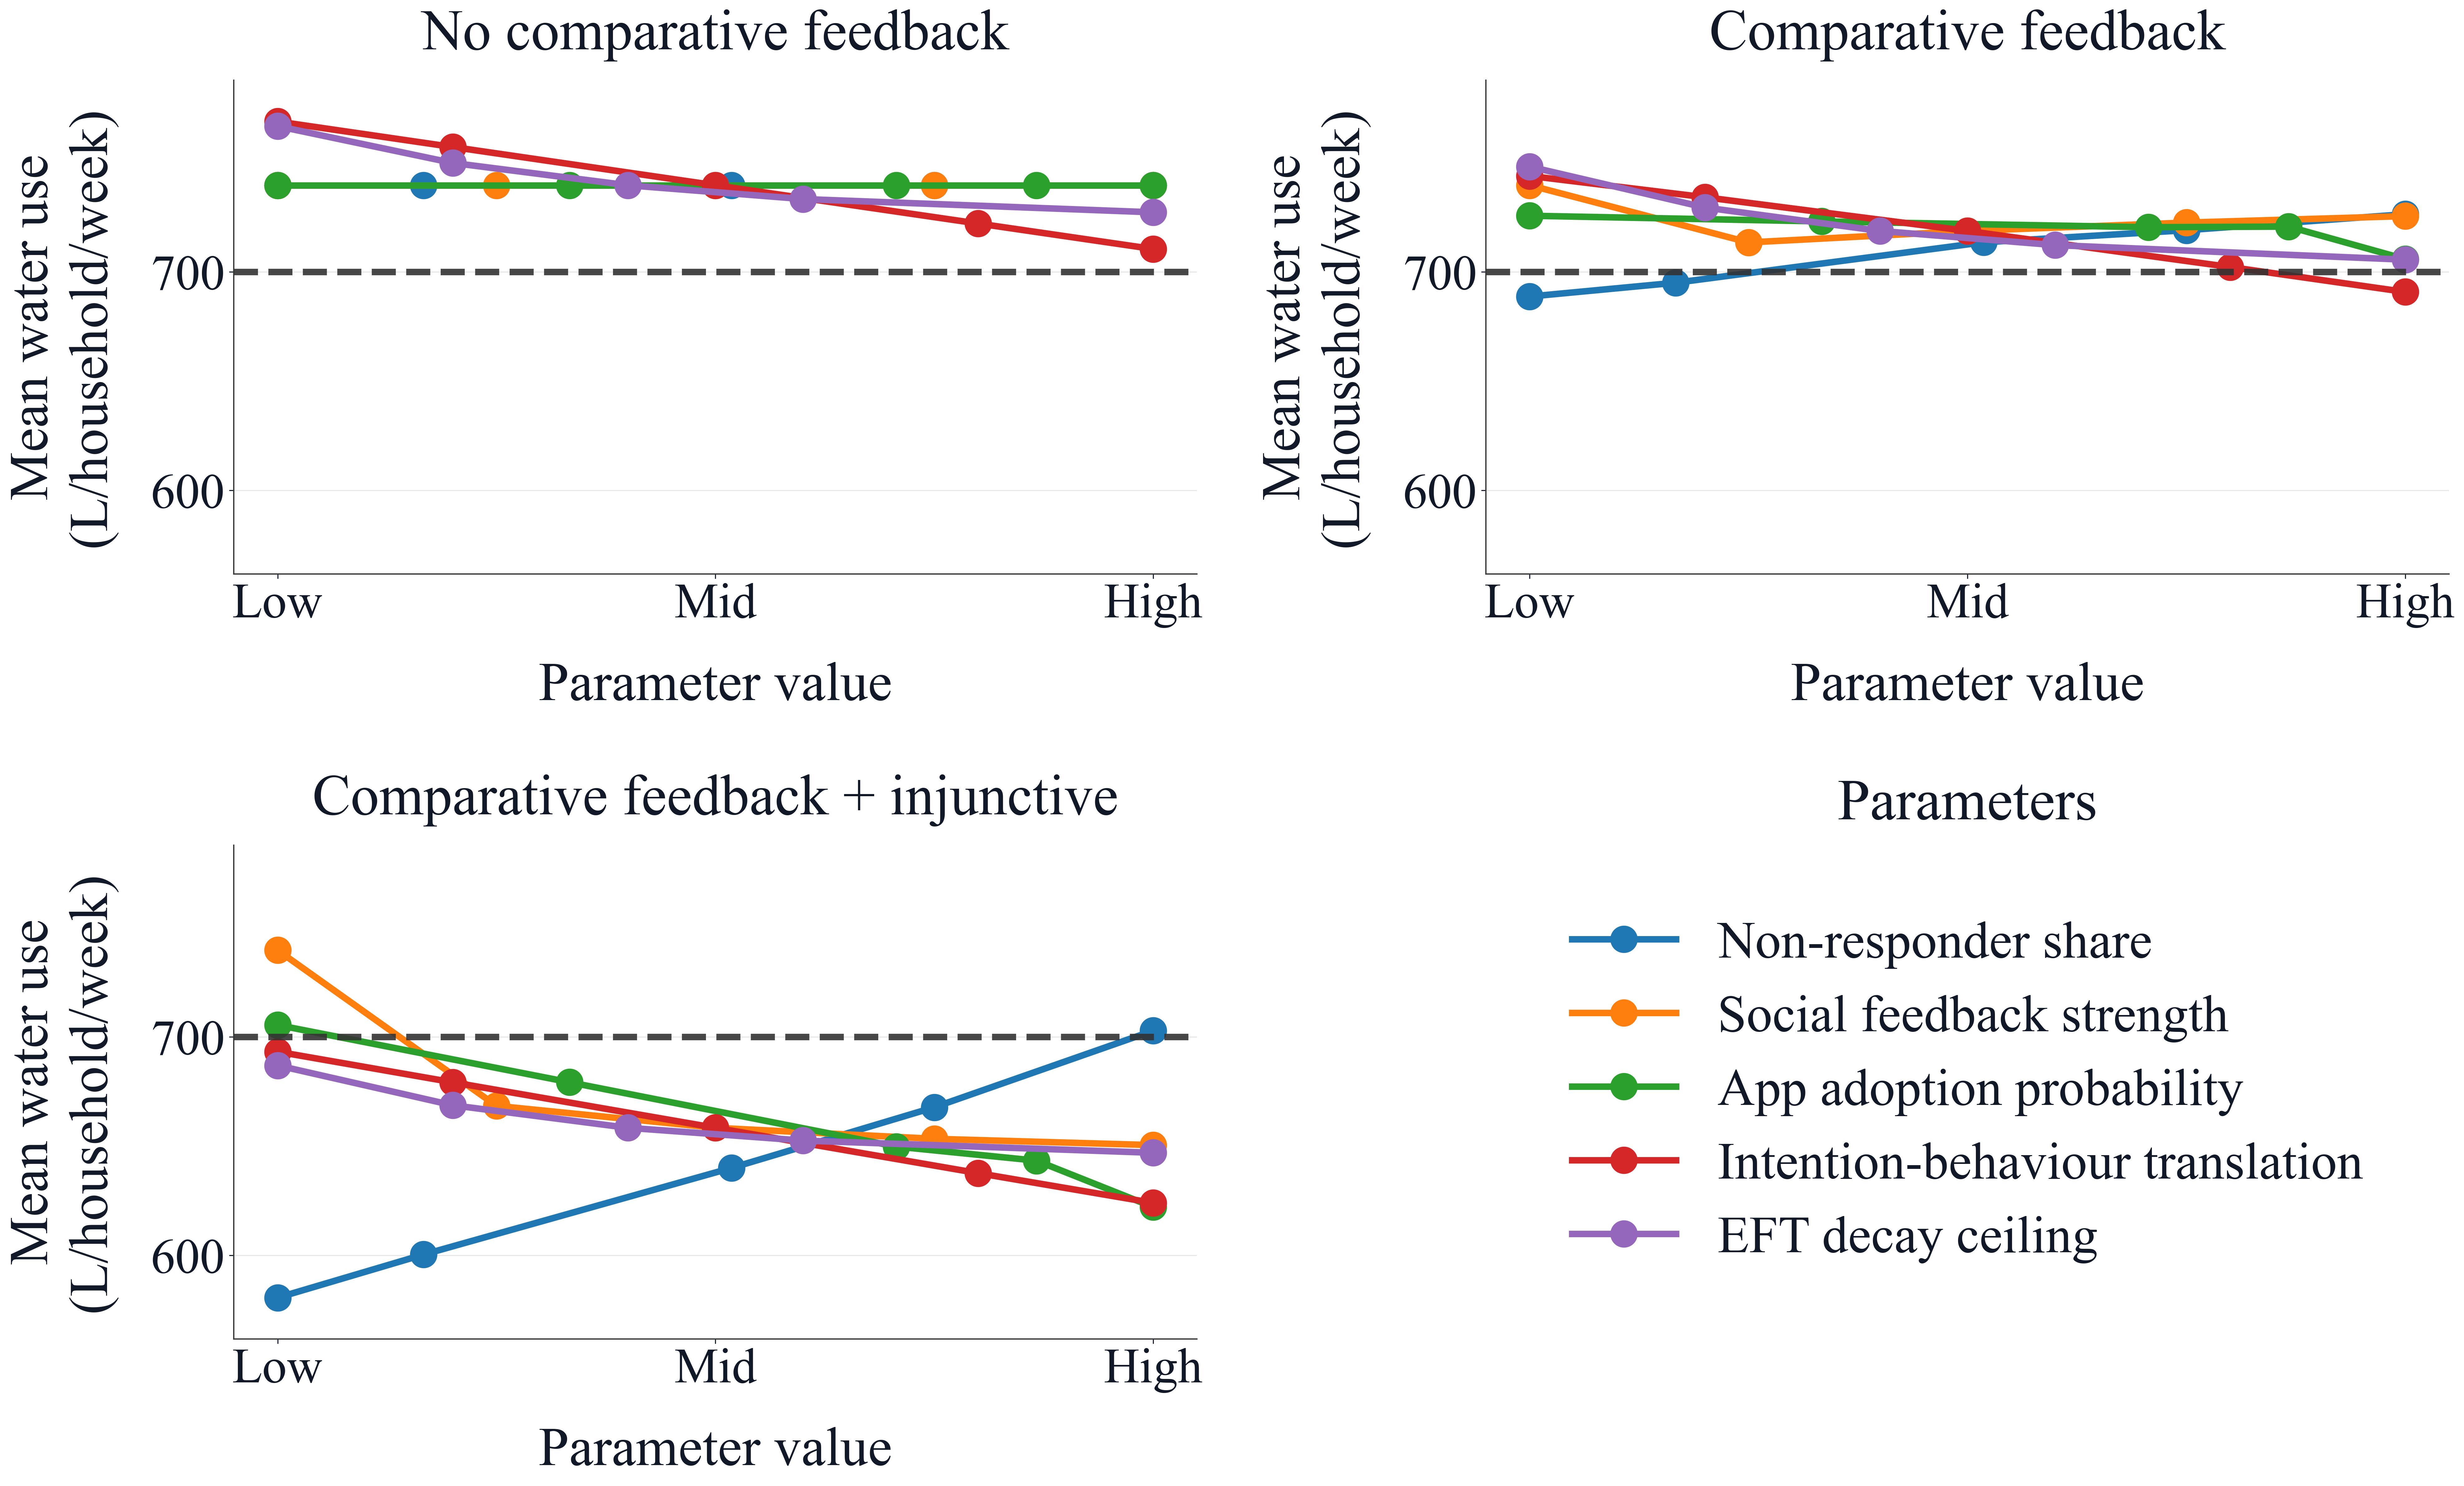

In [48]:
TopN  = 5
EndpointColumn = "endpoint_mean_water"

TopParameters = SensitivityRankingTable.sort_values("rank").head(TopN)["parameter"].tolist()

ParameterLabels = {
    "alpha_IB":                         "Intention-behaviour translation",
    "social_feedback_strength":         "Social feedback strength",
    "app_adoption_probability":         "App adoption probability",
    "tau_max_EFT":                      "EFT decay ceiling",
    "tau0_EFT":                         "Initial EFT decay constant",
    "mu_EFT":                           "EFT decay growth rate",
    "tau_max_info":                     "Info decay ceiling",
    "tau0_info":                        "Initial info decay constant",
    "mu_info":                          "Info decay growth rate",
    "lnk_pathway_strength":             "ln(k) pathway strength",
    "DeltaEFT":                         "Delta EFT",
    "lambda_EFT":                       "EFT saturation rate",
    "nonresponder_share_P0":            "Non-responder share",
    "social_responsiveness_sigma":      "Social responsiveness spread",
    "voluntary_monthly_participation":  "Monthly participation",
    "april_intervention_participation": "April participation",
    "weekly_toilet_flushes":            "Weekly toilet flushes",
    "small_flush_litres":               "Small flush litres",
    "full_flush_litres":                "Full flush litres",
    "washing_machine_litres":           "Washing machine litres",
    "eco_mode_saving":                  "Eco-mode saving",
    "water_off_duration":               "Shower water-off duration",
}

# prepare data
PlotData = SensitivityScreeningRaw[
    SensitivityScreeningRaw["parameter"].isin(TopParameters)].copy()
PlotData["value_min"] = PlotData.groupby("parameter")["value"].transform("min")
PlotData["value_max"] = PlotData.groupby("parameter")["value"].transform("max")
PlotData["relative_value"] = np.where(
    PlotData["value_max"] == PlotData["value_min"], 0.5,
    (PlotData["value"] - PlotData["value_min"])
    / (PlotData["value_max"] - PlotData["value_min"]),
)
PlotData["parameter_label"] = (
    PlotData["parameter"].map(ParameterLabels).fillna(PlotData["parameter"])
)

Colors      = plt.cm.tab10.colors
ParamColors = {param: Colors[i % len(Colors)] for i, param in enumerate(TopParameters)}

AllY   = PlotData[EndpointColumn].dropna()
YPad   = (AllY.max() - AllY.min()) * 0.10
YLim   = (AllY.min() - YPad, AllY.max() + YPad)

# Fonts
DPI = 300
plt.rcParams.update({
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":             38,
    "axes.titlesize":        44,
    "axes.labelsize":        42,
    "xtick.labelsize":       38,
    "ytick.labelsize":       38,
    "axes.titlepad":         24,
    "axes.labelpad":         26,
    "lines.linewidth":       5.0,
    "lines.markersize":      20,
})

# place figure
Fig = plt.figure(figsize=(26, 16), dpi=DPI)

gs = gridspec.GridSpec(
    2, 2, figure=Fig,
    width_ratios=[1.0, 1.0],
    height_ratios=[1.0, 1.0],
    left=0.07, right=0.98, top=0.94, bottom=0.10,
    wspace=0.30, hspace=0.55
)

Ax1 = Fig.add_subplot(gs[0, 0])
Ax2 = Fig.add_subplot(gs[0, 1])
Ax3 = Fig.add_subplot(gs[1, 0])
Axes = [Ax1, Ax2, Ax3]



LegendAx = Fig.add_subplot(gs[1, 1])
LegendAx.axis("off")

# Scenario‑plots
for Ax, ScenarioName in zip(Axes, ScenarioOrder):
    ScenData = PlotData[PlotData["scenario"] == ScenarioName].copy()

    for Param in TopParameters:
        PD = ScenData[ScenData["parameter"] == Param].sort_values("relative_value")
        if PD.empty:
            continue
        Ax.plot(
            PD["relative_value"], PD[EndpointColumn],
            marker="o",
            color=ParamColors[Param],
        )

    Ax.axhline(
        WaterTarget, linestyle="--", linewidth=5.0,
        color="#333333", alpha=0.9, zorder=3,
    )

    
    Ax.set_title(ScenarioName, fontweight="normal")
    Ax.set_xlabel("Parameter value", fontweight="normal")
    Ax.set_ylabel("Mean water use\n(L/household/week)", fontweight="normal")
    Ax.set_xticks([0, 0.5, 1.0])
    Ax.set_xticklabels(["Low", "Mid", "High"])
    Ax.set_ylim(YLim)
    Ax.grid(axis="y", alpha=0.3)
    Ax.spines[["top", "right"]].set_visible(False)

# Legend
legend_handles = [
    Line2D([0], [0],
           color=ParamColors[param],
           marker="o",
           linestyle="-",
           linewidth=5.0,
           markersize=20)
    for param in TopParameters
]
legend_labels = [ParameterLabels.get(p, p) for p in TopParameters]

LegendAx.legend(
    legend_handles,
    legend_labels,
    loc="center",
    fontsize=40,
    frameon=False
)
LegendAx.set_title("Parameters", fontsize=45, fontweight="normal", pad=20)

Fig.savefig("sensitivity_plots_2plus1_with_legend_equal_sizes.png",
            dpi=DPI, bbox_inches="tight")
plt.show()

## References

Algemene Rekenkamer. (2025). *Drinkwater onder druk: Drinkwaterbesparing – tijd voor resultaten*. Algemene Rekenkamer. https://www.rekenkamer.nl/documenten/2025/05/13/drinkwater-onder-druk

Bakker, J., van der Mooren, F., & Boonstra, H. J. (2022a). *Watergebruik Thuis (WGT) 2021*. Centraal Bureau voor de Statistiek. https://www.cbs.nl/nl-nl/longread/aanvullende-statistische-diensten/2022/watergebruik-thuis--wgt---2021

Bakker, J., van der Mooren, F., & Boonstra, H. J. (2022b). *Watergebruik Thuis (WGT) 2021 – 7. Het toilet*. Centraal Bureau voor de Statistiek. https://www.cbs.nl/nl-nl/longread/aanvullende-statistische-diensten/2022/watergebruik-thuis--wgt---2021/7-het-toilet

Brent, D. A., Cook, J. H., & Olsen, S. (2015). Social comparisons, household water use, and participation in utility conservation programs: Evidence from three randomized trials. *Journal of the Association of Environmental and Resource Economists, 2*(4), 597–627.

Centraal Bureau voor de Statistiek. (2023). *Hoeveel liter water gebruiken we per dag?* https://longreads.cbs.nl/nederland-in-cijfers-2023/hoeveel-liter-water-gebruiken-we-per-dag/

Duan, B., Gao, J., Wu, W., Cao, H., Guo, W., Wang, J., Zhang, S., Wen, C., Tian, Y., & Shen, C. (2025). Evaluating the dynamic psychological and behavioral changes of water-saving in public buildings under effective interventions. *Water Resources Research, 61*(7), e2024WR037749.

Ferraro, P. J., & Price, M. K. (2013). Using nonpecuniary strategies to influence behavior: Evidence from a large-scale field experiment. *Review of Economics and Statistics, 95*(1), 64–73.

Fowlie, M., Wolfram, C., Spurlock, C. A., Todd-Blick, A., Baylis, P., & Cappers, P. (2021). Default effects and follow-on behavior: Evidence from an electricity pricing program. *The Review of Economic Studies, 88*(6), 2886–2934. https://doi.org/10.1093/restud/rdab018

Koop, S. H. A., Clevers, S. H. P., Blokker, E. J. M., & Brouwer, S. (2021). Public attitudes towards digital water meters for households. *Sustainability, 13*(11), 6440.

López Zavala, M. Á., Castillo Vega, R., & López Miranda, R. A. (2016). Potential of rainwater harvesting and greywater reuse for water consumption reduction and wastewater minimization. *Water, 8*(6), 264.

MacLeod, S., Reynolds, M. G., & Lehmann, H. (2018). The mitigating effect of repeated memory reactivations on forgetting. *npj Science of Learning, 3*(1), 9.

Mellis, A. M., Snider, S. E., Deshpande, H. U., LaConte, S. M., & Bickel, W. K. (2019). Practicing prospection promotes patience: Repeated episodic future thinking cumulatively reduces delay discounting. *Drug and Alcohol Dependence, 204*, 107507.

Milieu Centraal. (2023). *Kluswijzer waterbesparende douchekop*. https://www.milieucentraal.nl/media/q1bb4qtr/kluswijzer-waterbesparende-douchekop.pdf

Otaki, Y., Onuki, Y., & Hosokawa, Y. (2024). Influence of financial incentive and nudge, alone and combined, on water-saving behaviors. *Sustainable Futures, 7*, 100224.

Rahman, F. A., Amalia, T. D., & Lutfi, M. (2021). *Reducing forgetting rate in EFL students using a spaced repetition-powered digital game-based learning application*. Open Science Framework.

Ramli, U., Nancarrow, C., & Spaargaren, G. (2021). Social norms based eco-feedback for household water consumption. *Sustainability, 13*(5), 2796. https://doi.org/10.3390/su13052796

Rosa, G., & Ghisi, E. (2021). Water quality and financial analysis of a system combining rainwater and greywater in a house. *Water, 13*(7), 930.

Rung, J. M., & Madden, G. J. (2018). Experimental reductions of delay discounting and impulsive choice: A systematic review and meta-analysis. *Journal of Experimental Psychology: General, 147*(9), 1349–1381.

Schacter, D. L. (2012). Adaptive constructive processes and the future of memory. *American Psychologist, 67*(8), 603–613.

Schultz, P. W., Javey, S., & Sorokina, A. (2019). Social comparison as a tool to promote residential water conservation. *Frontiers in Water, 1*, 2.

Schultz, P. W., Nolan, J. M., Cialdini, R. B., Goldstein, N. J., & Griskevicius, V. (2007). The constructive, destructive, and reconstructive power of social norms. *Psychological Science, 18*(5), 429–434.

Sheeran, P., & Gollwitzer, P. M. (2015). The intention–behaviour gap. *Social and Personality Psychology Compass, 9*(3), 121–133. https://doi.org/10.1111/spc3.12160

Vitens. (2024). *Eco wassen*. https://www.vitens.nl/Over-water/Water-besparen/Wasmachine/Eco-wassen

Vitens. (2026). *Scheer je huid met de kraan uit*. https://www.vitens.nl/over-vitens/pers-en-nieuws/nieuws/scheer-je-huid-met-de-kraan-uit

Wang, L., & Yang, J. (2024). The influence of repeated study and repeated testing on the testing effect and the transfer effect over time. *Memory & Cognition, 52*(3), 476–490.
